# Stage 5 -- Dimensionality Reduction

**Goal:** reduce the 10,000-dimensional TF-IDF matrix down to a much smaller number of dimensions that (a) a clustering algorithm can work with effectively, and (b) can be visualized in 2D to sanity-check whether topic structure exists at all before we commit to a clustering method in Stage 6.

### Methodology
**TF-IDF (10,000 dims) -> TruncatedSVD (100 dims) -> UMAP (2 dims, for visualization)**

- **TruncatedSVD** (the sparse-matrix-compatible version of PCA, equivalent to classical Latent Semantic Analysis for text) finds the directions of maximum variance and projects onto the top N of them. Linear, good at capturing global structure, computationally cheap.
- **UMAP** is non-linear and much better at preserving local neighborhood structure -- which is what actually produces visually meaningful, well-separated clusters in a 2D plot. Running UMAP directly on 10,000 raw dimensions is slow and less effective, so we first compress with SVD, then let UMAP work with a much smaller, denser input.

We will also save a higher-dimensional SVD output (not just the 2D UMAP one) for Stage 6 -- clustering is often done on the ~50-100 dim SVD space directly (or a similarly-dimensioned UMAP output), since collapsing all the way to 2D for clustering itself can lose too much information; 2D is primarily for human visualization.

In [1]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
import joblib

tfidf_matrix = sp.load_npz("../data/processed/tfidf_matrix.npz")
df = pd.read_parquet("../data/processed/arxiv_with_features_meta.parquet")

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Metadata shape:", df.shape)

TF-IDF matrix shape: (30000, 10000)
Metadata shape: (30000, 7)


## Step 1: TruncatedSVD -- how many components?

Rather than picking a component count arbitrarily, we fit SVD with a generous number of components first, then look at **explained variance** -- how much of the original data's variance is captured as we add more components -- and pick a number where returns are clearly diminishing. This is the same logic as an "elbow plot" in other contexts.

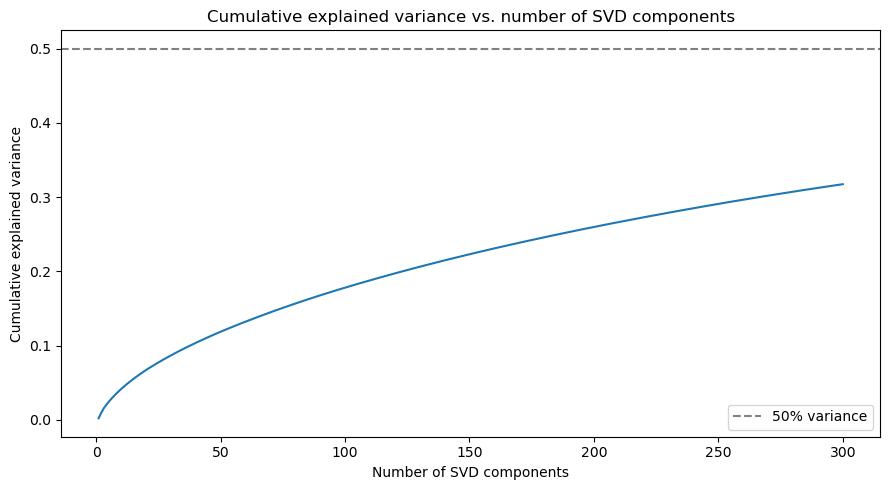

Variance explained by 50 components: 11.9%
Variance explained by 100 components: 17.8%
Variance explained by 200 components: 26.0%
Variance explained by 300 components: 31.7%


In [2]:
svd_probe = TruncatedSVD(n_components=300, random_state=42)
svd_probe.fit(tfidf_matrix)

cumulative_variance = np.cumsum(svd_probe.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 301), cumulative_variance)
plt.axhline(y=0.5, color="gray", linestyle="--", label="50% variance")
plt.xlabel("Number of SVD components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative explained variance vs. number of SVD components")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Variance explained by 50 components: {cumulative_variance[49]:.1%}")
print(f"Variance explained by 100 components: {cumulative_variance[99]:.1%}")
print(f"Variance explained by 200 components: {cumulative_variance[199]:.1%}")
print(f"Variance explained by 300 components: {cumulative_variance[299]:.1%}")

**Note on TF-IDF + SVD specifically:** unlike, say, image data, sparse high-dimensional TF-IDF data typically has variance spread thinly across *many* components rather than concentrated in a few -- so don't be surprised if even 100-200 components only capture a modest percentage of total variance (often 20-40% is normal and workable for text, unlike the 90%+ you might expect for other data types). What matters more than the raw percentage is that most of the *usable topical signal* is captured, which we'll sanity-check visually in Step 3.

Cumulative explained variance rises steadily without a sharp elbow — 11.9% at 50 components, 17.8% at 100, climbing to 31.7% at 300 — consistent with sparse TF-IDF data where topical signal is distributed across many components rather than concentrated in a few. I chose 100 components as a practical balance: it captures meaningfully more signal than 50 while keeping Stage 6 clustering computationally light, and its adequacy is better judged by the downstream UMAP visualization (Step 3) than by the raw variance percentage alone.

## Step 2: Fit the final SVD with your chosen component count

Update `N_COMPONENTS` below based on your observation above before running -- a common, defensible choice for this kind of corpus size is somewhere in the 50-150 range, balancing captured variance against keeping Stage 6 computationally light.

In [3]:
N_COMPONENTS = 100  # adjust based on your Step 1 observation

svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
svd_embeddings = svd.fit_transform(tfidf_matrix)

print("SVD-reduced shape:", svd_embeddings.shape)
print(f"Total variance explained: {svd.explained_variance_ratio_.sum():.1%}")

SVD-reduced shape: (30000, 100)
Total variance explained: 17.7%


## Step 3: UMAP for 2D visualization

This is the first point in the whole pipeline where you can actually *see* whether meaningful topic structure exists in the data -- distinct, separated blobs suggest real clusterable structure; a single undifferentiated blob would suggest the feature engineering needs revisiting before Stage 6.

In [4]:
import umap

reducer_2d = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
umap_2d = reducer_2d.fit_transform(svd_embeddings)

print("UMAP 2D shape:", umap_2d.shape)

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 2D shape: (30000, 2)


**Note:** UMAP can take a few minutes on 30,000 points -- this is expected, unlike the earlier steps in this notebook.

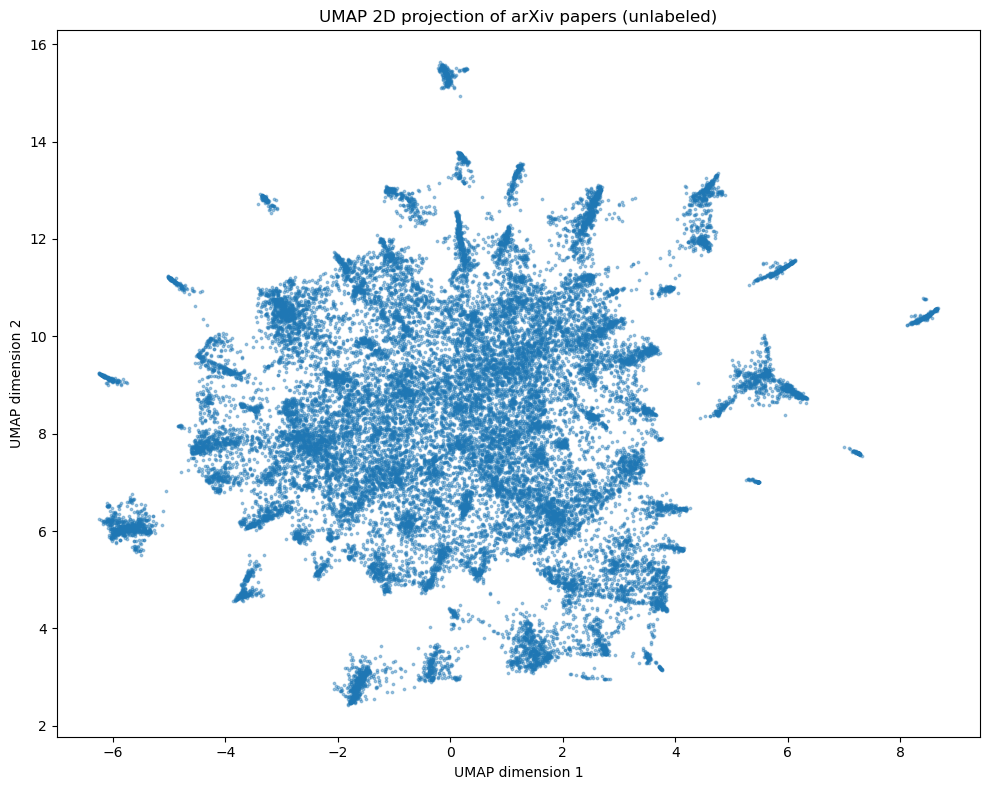

In [5]:
plt.figure(figsize=(10, 8))
plt.scatter(umap_2d[:, 0], umap_2d[:, 1], s=3, alpha=0.4)
plt.title("UMAP 2D projection of arXiv papers (unlabeled)")
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.tight_layout()
plt.show()

The projection shows a large, dense central mass alongside multiple smaller, clearly separated clusters and elongated streaks around the periphery — not one undifferentiated cloud. This is good evidence of real, clusterable topic structure. The dense center is consistent with Stage 2's finding that cs.LG and cs.AI dominate the sample and heavily co-occur, producing a large "core ML" region without sharp internal boundaries, while the distinct satellite groups likely correspond to more topically-specific sub-fields (e.g. computer vision, robotics, security) that separate more cleanly. This suggests Stage 6 clustering should find several well-defined smaller clusters plus one or more larger, more diffuse ones.

## Step 4: Same plot, colored by primary category (sanity check against known labels)

We have arXiv's own category tags as a rough, imperfect "ground truth". Coloring the same UMAP plot by each paper's *first* listed category lets us sanity-check: do papers that arXiv itself grouped together also end up visually near each other in our unsupervised projection? This does NOT need to be a perfect match (recall from Stage 2's EDA that categories heavily overlap and co-occur) -- but *some* visible structure aligning with categories is a good sign.

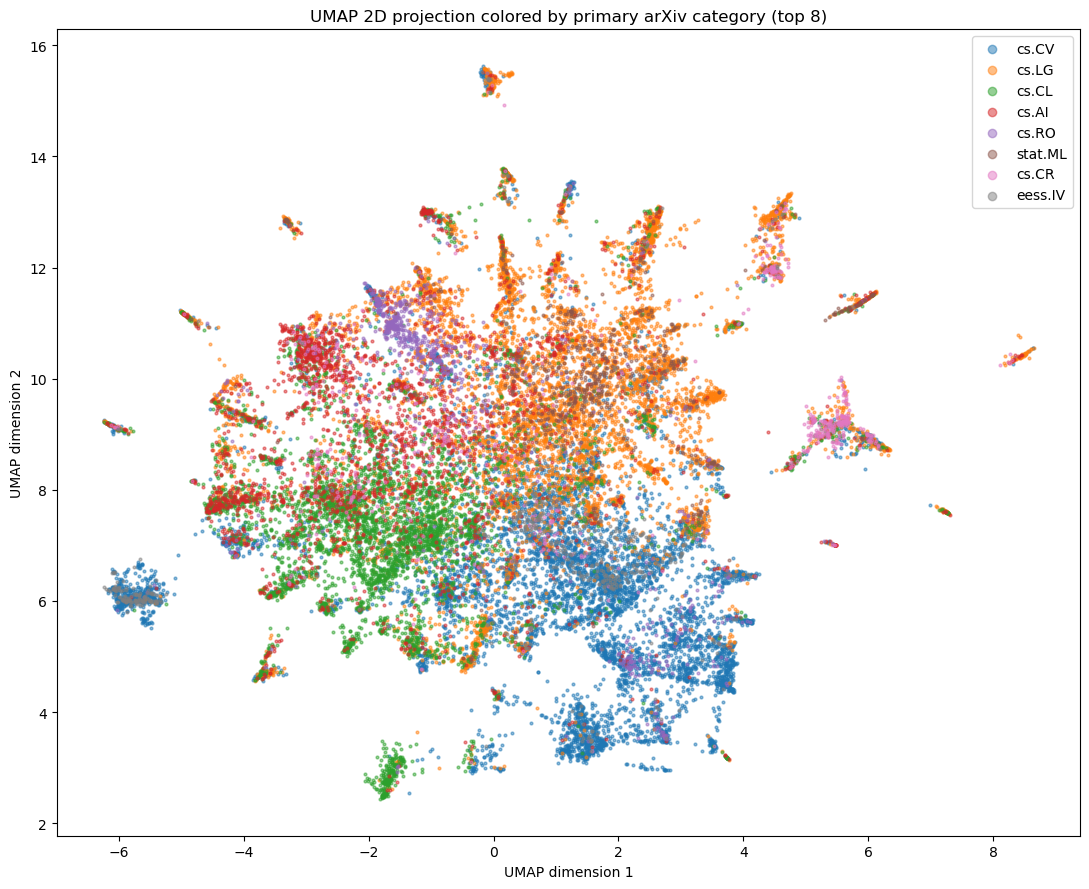

In [6]:
df["primary_category"] = df["categories"].str.split().str[0]
top_categories = df["primary_category"].value_counts().head(8).index.tolist()

plt.figure(figsize=(11, 9))
for cat in top_categories:
    mask = df["primary_category"] == cat
    plt.scatter(umap_2d[mask, 0], umap_2d[mask, 1], s=4, alpha=0.5, label=cat)

plt.title("UMAP 2D projection colored by primary arXiv category (top 8)")
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.legend(markerscale=3, loc="best")
plt.tight_layout()
plt.show()

Coloring by primary category confirms the pattern seen in Step 3: the smaller, peripheral clusters are strongly single-colored (e.g. the top-right and bottom-left satellite groups), showing that certain categories do separate cleanly in this projection. The large central mass, however, is a genuine mixture of colors with no single category dominating any sub-region — this matches Stage 2's finding that cs.LG and cs.AI dominate the sample and frequently co-occur as cross-listed tags, so papers from these categories don't separate from each other along category lines alone. This is a useful expectation to carry into Stage 6: cluster boundaries are more likely to reflect finer sub-topics within the ML/AI core than the coarse arXiv category labels themselves.

## Step 5: Save embeddings for Stage 6

We save both: the SVD embeddings (higher-dimensional, used for the actual clustering algorithm) and the UMAP 2D embeddings (used for visualizing the final clusters).

In [7]:
np.save("../data/processed/svd_embeddings.npy", svd_embeddings)
np.save("../data/processed/umap_2d_embeddings.npy", umap_2d)
joblib.dump(svd, "../data/processed/svd_model.joblib")
joblib.dump(reducer_2d, "../data/processed/umap_2d_model.joblib")

print("Saved: svd_embeddings.npy, umap_2d_embeddings.npy, svd_model.joblib, umap_2d_model.joblib")

Saved: svd_embeddings.npy, umap_2d_embeddings.npy, svd_model.joblib, umap_2d_model.joblib
